In [4]:
import torch
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms as T
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torchvision.models as models
import wandb

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('L')
        
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
            
        return image, label

# ====================== DATASETS Y DATALOADERS PARA TRANSFER LEARNING ======================

# Estadísticos de ImageNet
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Transforms para ResNet18 (3 canales + normalización ImageNet)
train_transform_tl = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),   # pasa de 1 canal a 3 canales "falsos" (R=G=B)
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transform_tl = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),   # igual en validación
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

data_dir = Path('Breast-Cancer-Dataset')
classes = [d.name for d in data_dir.iterdir() if d.is_dir()]
label_map = {name: i for i, name in enumerate(classes)}
num_classes = len(classes)

print(f"Clases encontradas: {label_map}")

file_paths = []
labels = []
for class_name, label_idx in label_map.items():
    class_dir = data_dir / class_name
    for img_path in class_dir.glob('*.[jp][pn]g'): 
        file_paths.append(str(img_path))
        labels.append(label_idx)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, 
    labels, 
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_dataset_tl = ImageDataset(train_paths, train_labels, transform=train_transform_tl)
val_dataset_tl   = ImageDataset(val_paths,   val_labels,   transform=val_transform_tl)

BATCH_SIZE = 32
train_loader_tl = DataLoader(train_dataset_tl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tl   = DataLoader(val_dataset_tl,   batch_size=BATCH_SIZE, shuffle=False)

print(f"[TL] Imágenes de entreno: {len(train_dataset_tl)}")
print(f"[TL] Imágenes de validación: {len(val_dataset_tl)}")


Clases encontradas: {'benign': 0, 'malignant': 1, 'normal': 2}
[TL] Imágenes de entreno: 624
[TL] Imágenes de validación: 156


In [ ]:
# ====================== CONFIGURACIÓN WANDB E HIPERPARÁMETROS (TRANSFER LEARNING) ======================

wandb.login(key="")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

torch.manual_seed(42)
np.random.seed(42)

wandb.init(
    project="breast-cancer-cnn",
    name="modelo-transfer-resnet18-v2",
    config={
        "architecture": "ResNet18-TL",
        "dataset": "Breast-Cancer",
        "epochs": 50,
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "AdamW",
        "weight_decay": 0.0001,
        "patience": 10,
        "num_classes": 3
    }
)

config = wandb.config

# ====================== MODELO Y OPTIMIZADOR (TRANSFER LEARNING) ======================

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Congelamos TODAS las capas MENOS LA CUARTA Y LA FC
for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, config.num_classes)

model = model.to(device)

print("Transfer Learning con ResNet18 configurado correctamente.")

learning_rate = config.learning_rate
NUM_EPOCHS = config.epochs

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    [
        {"params": model.fc.parameters(), "lr": 1e-3},
        {"params": model.layer4.parameters(), "lr": 1e-4},
    ],
    weight_decay=config.weight_decay
)

wandb.config.update({"class_weights": class_weights.cpu().numpy().tolist()})

# ====================== ENTRENAMIENTO (TRANSFER LEARNING) ======================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):

    # ----------- TRAIN -----------
    model.train()
    train_loss_sum = 0
    correct_train = 0
    n_train_samples = 0

    for images, labels in tqdm(train_loader_tl, desc=f"Train {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        n_train_samples += labels.size(0)
        correct_train += (pred == labels).sum().item()

    train_loss = train_loss_sum / n_train_samples
    train_acc = 100 * correct_train / n_train_samples

    # ----------- VALIDATION -----------
    model.eval()
    val_loss_sum = 0
    correct_val = 0
    n_val_samples = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader_tl, desc=f"Val {epoch+1}/{NUM_EPOCHS}"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            n_val_samples += labels.size(0)
            correct_val += (pred == labels).sum().item()

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss_sum / n_val_samples
    val_acc = 100 * correct_val / n_val_samples

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # ----------- LOGGING -----------
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc
    })

    # ----------- EARLY STOPPING -----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        wandb.run.summary["best_val_loss"] = best_val_loss
        wandb.run.summary["best_epoch"] = epoch + 1

        print("  ✓ Mejor val_loss")
    else:
        patience_counter += 1
        print(f"  No mejora ({patience_counter}/{config.patience})")

        if patience_counter >= config.patience:
            print("\n⛔ Early stopping activado.")
            break


# ====================== EVALUACIÓN FINAL ======================

print("\nEvaluando modelo final (últimos pesos del entrenamiento)…")
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader_tl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        _, pred = outputs.max(1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ["benign", "malignant", "normal"]

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        y_true=all_labels,
        preds=all_preds,
        class_names=class_names
    ),
    "roc_curve": wandb.plot.roc_curve(
        all_labels, all_probs, labels=class_names
    ),
    "pr_curve": wandb.plot.pr_curve(
        all_labels, all_probs, labels=class_names
    )
})

wandb.finish()
print("Evaluación final completada.")



wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


Usando dispositivo: cpu


Transfer Learning con ResNet18 configurado correctamente.


Val 1/50: 100%|██████████| 5/5 [00:06<00:00,  1.38s/it]


Epoch 1/50 | Train Loss: 0.8288 | Train Acc: 58.01% | Val Loss: 0.7250 | Val Acc: 72.44%
  ✓ Mejor val_loss


...

Epoch 10/50 | Train Loss: 0.0887 | Train Acc: 96.31% | Val Loss: 0.4409 | Val Acc: 87.18%
  No mejora (6/7)


Val 11/50: 100%|██████████| 5/5 [00:07<00:00,  1.54s/it]


Epoch 11/50 | Train Loss: 0.0863 | Train Acc: 96.79% | Val Loss: 0.4922 | Val Acc: 87.18%
  No mejora (7/7)

⛔ Early stopping activado.

Evaluando modelo final (últimos pesos del entrenamiento)…


epoch,▁▂▂▃▄▅▅▆▇▇█
train/accuracy,▁▅▆▆▆▇█▇███
train/loss,█▅▃▃▃▂▁▁▁▁▁
val/accuracy,▁▃▄▅▅▆▇████
val/loss,█▅▃▁▂▂▃▁▁▂▃
best_epoch,4
best_val_loss,0.39093
epoch,11
train/accuracy,96.79487
train/loss,0.08631
val/accuracy,87.17949


Evaluación final completada.


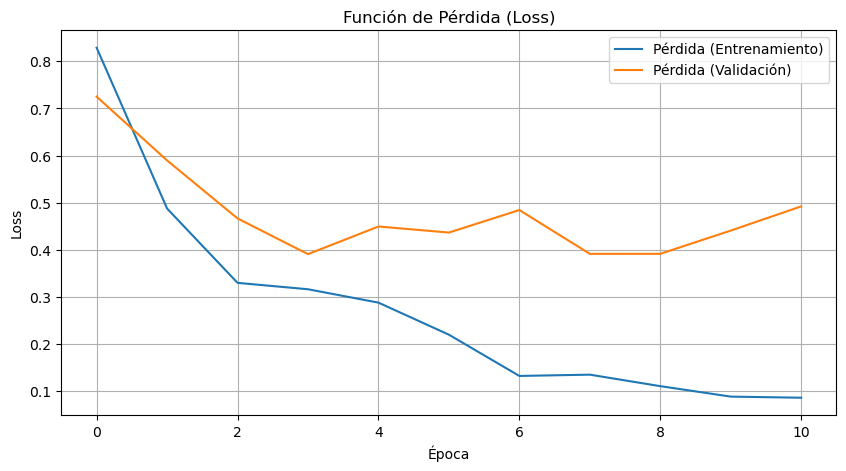

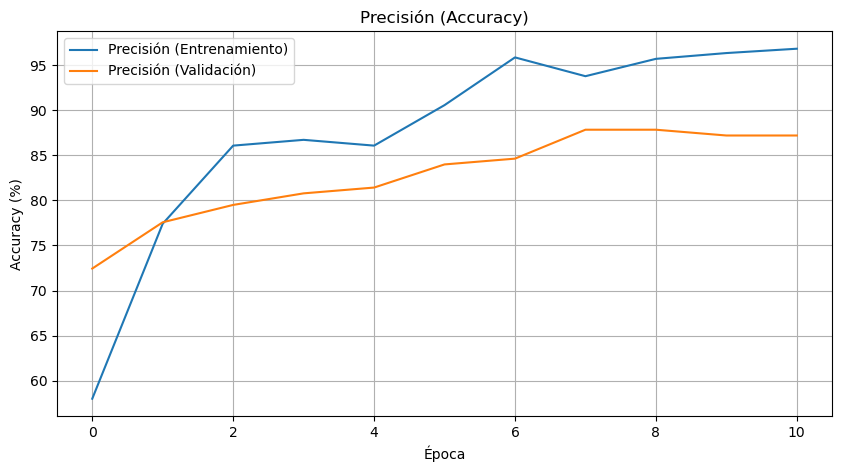

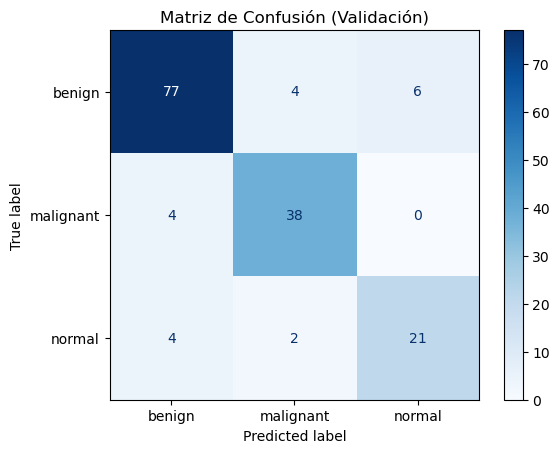

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Pérdida (Entrenamiento)')
plt.plot(history['val_loss'], label='Pérdida (Validación)')
plt.title('Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Precisión (Entrenamiento)')
plt.plot(history['val_acc'], label='Precisión (Validación)')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader_tl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Validación)')
plt.show()